In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df_preprocessed = pd.read_csv('C:/My_Projects/churn-prediction-mlops-pipeline/data/processed-data/preprocessed_data.csv')

In [32]:
# === Step 1: Drop irrelevant columns ===
# Drop 'customerID' and 'Churn' (but keep 'Churn_Label' for modeling)
df_feature = df_preprocessed.drop(columns=['customerID', 'Churn'], errors='ignore')

In [33]:
# === Step 2: Derived Features ===
df_feature['complaints_per_tenure'] = df_feature['total_complaints'] / (df_feature['tenure'] + 1)
df_feature['unresolved_ratio'] = df_feature['unresolved_complaints'] / (df_feature['total_complaints'] + 1)
df_feature['drop_rate_per_tenure'] = df_feature['call_drop_rate'] / (df_feature['tenure'] + 1)
df_feature['data_usage_per_tenure'] = df_feature['data_usage_gb'] / (df_feature['tenure'] + 1)

In [34]:
# === Step 3: Encode category columns ===
# Encode target
df_feature['Churn_Label'] = df_preprocessed['Churn'].map({'Yes': 1, 'No': 0})

In [36]:
# Binary encoding for yes/no columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_feature[col] = df_feature[col].map({'Yes': 1, 'No': 0})
df_feature['gender'] = df_feature['gender'].map({'Male': 1, 'Female': 0})


In [37]:
#Encode all other columns
multi_cat_cols = ['InternetService', 'PaymentMethod', 'TechSupport', 
                  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'StreamingTV', 'StreamingMovies', 'MultipleLines', 'Contract']

df_feature = pd.get_dummies(df_feature, columns=multi_cat_cols, drop_first=True)


C:\Users\nchan\AppData\Local\Temp\ipykernel_35200\4059931439.py:8: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


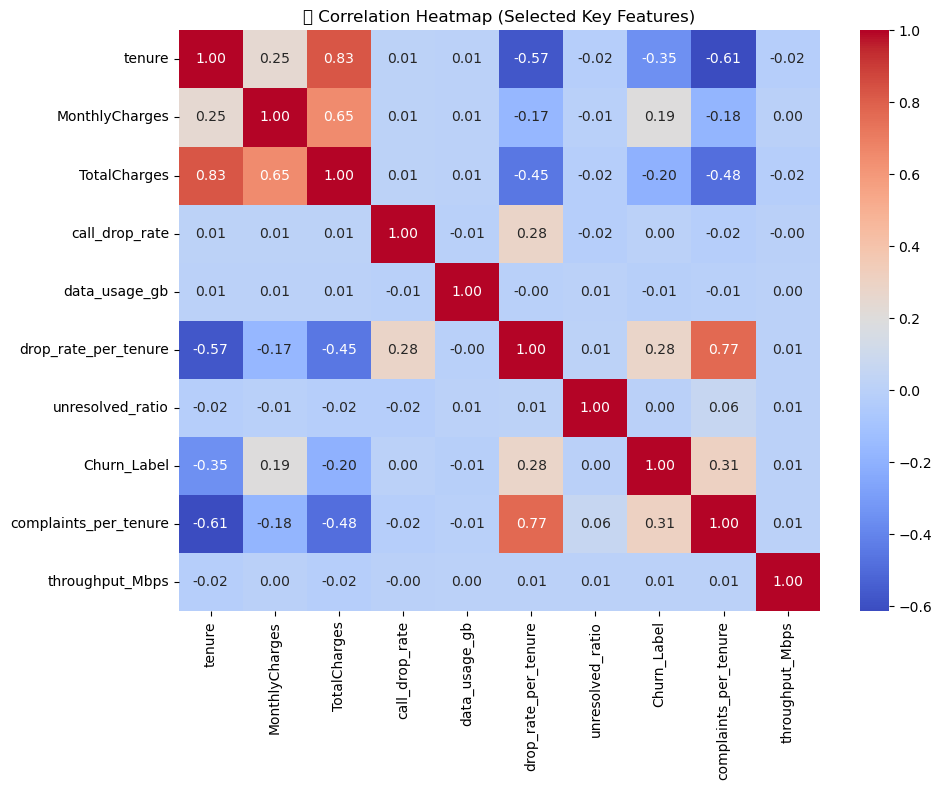

In [43]:
top_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'call_drop_rate',
                'data_usage_gb', 'drop_rate_per_tenure', 'unresolved_ratio',
                'Churn_Label', 'complaints_per_tenure', 'throughput_Mbps']

plt.figure(figsize=(10, 8))
sns.heatmap(df_feature[top_features].corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("🔍 Correlation Heatmap (Selected Key Features)")
plt.tight_layout()
plt.show()


In [44]:
# Drop highly correlated/redundant features
df_feature = df_feature.drop(columns=['TotalCharges'])

In [46]:
# Convert all boolean columns to integers
bool_cols = df_feature.select_dtypes(include=['bool']).columns
df_feature[bool_cols] = df_feature[bool_cols].astype(int)
# === Step 2: Derived Features ===
df_feature['complaints_per_tenure'] = df_feature['total_complaints'] / (df_feature['tenure'] + 1)
df_feature['unresolved_ratio'] = df_feature['unresolved_complaints'] / (df_feature['total_complaints'] + 1)
df_feature['drop_rate_per_tenure'] = df_feature['call_drop_rate'] / (df_feature['tenure'] + 1)
df_feature['data_usage_per_tenure'] = df_feature['data_usage_gb'] / (df_feature['tenure'] + 1)


In [49]:
# Save feature engineered data
df_feature.to_csv("C:/My_projects/churn-prediction-mlops-pipeline/data/processed-data/feature_engineered_data.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_preprocessed = pd.read_csv('C:/My_Projects/churn-prediction-mlops-pipeline/data/processed-data/preprocessed_data.csv')
# === Step 1: Drop irrelevant columns ===
# Drop 'customerID' and 'Churn' (but keep 'Churn_Label' for modeling)
df_feature = df_preprocessed.drop(columns=['customerID', 'Churn'], errors='ignore')
# === Step 3: Encode category columns ===
# Encode target
df_feature['Churn_Label'] = df_preprocessed['Churn'].map({'Yes': 1, 'No': 0})
# Binary encoding for yes/no columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_feature[col] = df_feature[col].map({'Yes': 1, 'No': 0})
df_feature['gender'] = df_feature['gender'].map({'Male': 1, 'Female': 0})
#Encode all other columns
multi_cat_cols = ['InternetService', 'PaymentMethod', 'TechSupport', 
                  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'StreamingTV', 'StreamingMovies', 'MultipleLines', 'Contract']

df_feature = pd.get_dummies(df_feature, columns=multi_cat_cols, drop_first=True)
top_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'call_drop_rate',
                'data_usage_gb', 'drop_rate_per_tenure', 'unresolved_ratio',
                'Churn_Label', 'complaints_per_tenure', 'throughput_Mbps']

plt.figure(figsize=(10, 8))
sns.heatmap(df_feature[top_features].corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("🔍 Correlation Heatmap (Selected Key Features)")
plt.tight_layout()
plt.show()
# Drop highly correlated/redundant features
df_feature = df_feature.drop(columns=['TotalCharges'])
# Convert all boolean columns to integers
bool_cols = df_feature.select_dtypes(include=['bool']).columns
df_feature[bool_cols] = df_feature[bool_cols].astype(int)
# === Step 2: Derived Features ===
df_feature['complaints_per_tenure'] = df_feature['total_complaints'] / (df_feature['tenure'] + 1)
df_feature['unresolved_ratio'] = df_feature['unresolved_complaints'] / (df_feature['total_complaints'] + 1)
df_feature['drop_rate_per_tenure'] = df_feature['call_drop_rate'] / (df_feature['tenure'] + 1)
df_feature['data_usage_per_tenure'] = df_feature['data_usage_gb'] / (df_feature['tenure'] + 1)
# Save feature engineered data
df_feature.to_csv("C:/My_projects/churn-prediction-mlops-pipeline/data/processed-data/feature_engineered_data.csv", index=False)